# Algorithms & Data Structures — Foundations

An **algorithm** is a finite, unambiguous procedure that transforms an input into a desired output; a **data structure** is the way that data is organized so an algorithm can act on it efficiently. The central question of this notebook is *how does the cost of an algorithm grow as its input grows*, captured by the asymptotic relation

$$ f(n) = O(g(n)) \iff \exists\, c>0,\ n_0 \ \text{s.t.}\ \forall n \ge n_0,\ f(n) \le c\,g(n). $$

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.figsize'] = (8, 5)

## Growth Rates

Big-O classifies functions by their dominant term as $n \to \infty$; constants and lower-order terms are discarded. The common classes, in increasing order of cost, are

$$ O(1) \prec O(\log n) \prec O(n) \prec O(n\log n) \prec O(n^2) \prec O(2^n) \prec O(n!). $$

Slide $n$ to see how dramatically the slower classes diverge while the fast ones stay flat.

In [ ]:
classes = {
    'O(1)':        lambda n: np.ones_like(n, dtype=float),
    'O(log n)':    lambda n: np.log2(n),
    'O(n)':        lambda n: n.astype(float),
    'O(n log n)':  lambda n: n * np.log2(n),
    'O(n^2)':      lambda n: n.astype(float)**2,
    'O(2^n)':      lambda n: 2.0**n,
}

def plot_growth(nmax, logscale):
    n = np.arange(1, nmax + 1)
    fig, ax = plt.subplots()
    for name, f in classes.items():
        ax.plot(n, f(n), label=name, lw=2)
    if logscale:
        ax.set_yscale('log')
    else:
        ax.set_ylim(0, classes['O(n^2)'](np.array([nmax]))[0] * 1.1)
    ax.set_xlabel('input size n'); ax.set_ylabel('operations')
    ax.set_title('Asymptotic growth of complexity classes')
    ax.legend(loc='upper left')
    plt.show()

nmax_s = widgets.IntSlider(value=20, min=5, max=60, step=1, description='n max')
log_s  = widgets.Checkbox(value=False, description='log scale')
ui = widgets.HBox([nmax_s, log_s])
out = widgets.interactive_output(plot_growth, {'nmax': nmax_s, 'logscale': log_s})
display(ui, out)

Output()

## Measuring Cost Empirically

Theoretical class and measured runtime should agree up to constant factors. Counting the elementary operations of a *linear scan* (max-finding) versus a *quadratic* all-pairs check confirms

$$ T_{\text{scan}}(n) = n, \qquad T_{\text{pairs}}(n) = \binom{n}{2} = \tfrac{n(n-1)}{2} = O(n^2). $$

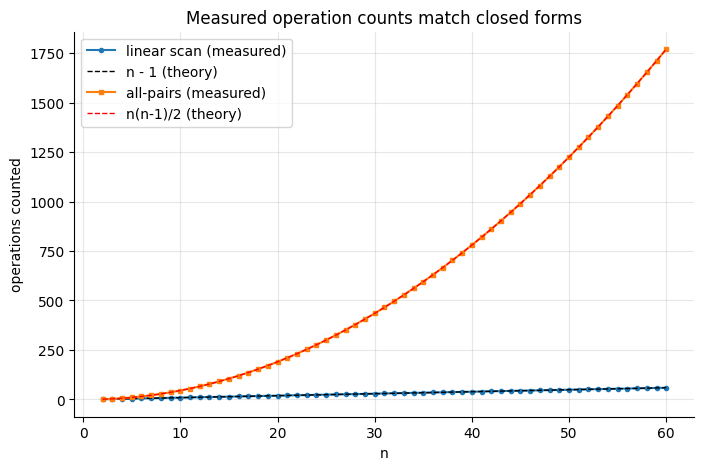

In [3]:
def count_scan(n):
    a = np.random.rand(n)
    ops = 0
    best = a[0]
    for x in a[1:]:
        ops += 1                 # one comparison per element
        if x > best: best = x
    return ops

def count_pairs(n):
    a = np.random.rand(n)
    ops = 0
    for i in range(n):
        for j in range(i + 1, n):
            ops += 1             # one comparison per unordered pair
            _ = a[i] > a[j]
    return ops

sizes = np.arange(2, 61)
scan = np.array([count_scan(n) for n in sizes])
pairs = np.array([count_pairs(n) for n in sizes])

fig, ax = plt.subplots()
ax.plot(sizes, scan, 'o-', ms=3, label='linear scan (measured)')
ax.plot(sizes, sizes - 1, 'k--', lw=1, label='n - 1 (theory)')
ax.plot(sizes, pairs, 's-', ms=3, label='all-pairs (measured)')
ax.plot(sizes, sizes*(sizes-1)/2, 'r--', lw=1, label='n(n-1)/2 (theory)')
ax.set_xlabel('n'); ax.set_ylabel('operations counted')
ax.set_title('Measured operation counts match closed forms')
ax.legend()
plt.show()

## Best, Worst, and Average Case

The same algorithm can have different costs depending on the input arrangement. Linear search for a target costs $O(1)$ if the target is first, $O(n)$ if last or absent, and on average

$$ \mathbb{E}[\text{comparisons}] = \frac{1}{n}\sum_{k=1}^{n} k = \frac{n+1}{2}. $$

The histogram below shows the distribution of comparison counts over many random target positions.

In [4]:
def linear_search(a, target):
    for i, x in enumerate(a):
        if x == target:
            return i + 1          # comparisons used
    return len(a)                 # absent: scanned all

def search_distribution(n, trials, present):
    a = np.arange(n)
    counts = []
    for _ in range(trials):
        target = np.random.randint(n) if present else n + 1
        counts.append(linear_search(a, target))
    return np.array(counts)

def plot_dist(n, present):
    counts = search_distribution(n, 4000, present)
    fig, ax = plt.subplots()
    ax.hist(counts, bins=min(n, 40), color='steelblue', alpha=0.8)
    mean = counts.mean()
    ax.axvline(mean, color='red', lw=2, label=f'mean = {mean:.1f}')
    ax.axvline((n + 1) / 2, color='green', ls='--', lw=2, label=f'(n+1)/2 = {(n+1)/2:.1f}')
    ax.set_xlabel('comparisons'); ax.set_ylabel('frequency')
    ax.set_title(f'Linear search cost, n={n}, target {"present" if present else "absent"}')
    ax.legend()
    plt.show()

n_s = widgets.IntSlider(value=50, min=10, max=200, step=10, description='n')
pres_s = widgets.Checkbox(value=True, description='target present')
ui = widgets.HBox([n_s, pres_s])
out = widgets.interactive_output(plot_dist, {'n': n_s, 'present': pres_s})
display(ui, out)

Output()

## Paradigm: Divide & Conquer

A problem is split into independent subproblems, solved recursively, and combined. When a size-$n$ problem splits into $a$ subproblems of size $n/b$ with combine cost $O(n^d)$, the **Master Theorem** gives

$$ T(n) = a\,T\!\left(\tfrac{n}{b}\right) + O(n^d) \;\Rightarrow\;
T(n) = \begin{cases} O(n^d) & d > \log_b a \\ O(n^d \log n) & d = \log_b a \\ O(n^{\log_b a}) & d < \log_b a. \end{cases}$$

Vary $a, b, d$ to see which regime dominates and how the recursion tree's cost-per-level behaves.

In [5]:
def master_regime(a, b, d):
    crit = np.log(a) / np.log(b)
    if d > crit:   return crit, f'O(n^{d}) — root dominates'
    if abs(d - crit) < 1e-9: return crit, f'O(n^{d} log n) — balanced'
    return crit, f'O(n^{crit:.2f}) — leaves dominate'

def plot_levels(a, b, d):
    crit, label = master_regime(a, b, d)
    n0 = b**8
    levels = np.arange(0, 9)
    sub_size = n0 / (b ** levels.astype(float))
    work = (a ** levels) * (sub_size ** d)   # total work at each level
    fig, ax = plt.subplots()
    ax.bar(levels, work, color='darkorange', alpha=0.8)
    ax.set_xlabel('recursion level'); ax.set_ylabel('work at level')
    ax.set_title(f'a={a}, b={b}, d={d}  →  log_b a = {crit:.2f}\n{label}')
    plt.show()

a_s = widgets.IntSlider(value=2, min=1, max=8, description='a (subproblems)')
b_s = widgets.IntSlider(value=2, min=2, max=4, description='b (factor)')
d_s = widgets.FloatSlider(value=1.0, min=0.0, max=3.0, step=0.5, description='d (combine)')
ui = widgets.VBox([a_s, b_s, d_s])
out = widgets.interactive_output(plot_levels, {'a': a_s, 'b': b_s, 'd': d_s})
display(ui, out)

Output()

## Paradigm: Greedy vs. Exhaustive

A **greedy** algorithm makes the locally optimal choice at each step, running in low polynomial time, while **exhaustive** search guarantees the optimum at exponential cost. For the 0/1 knapsack with capacity $W$, greedy maximizes density $v_i/w_i$ but can miss the true optimum

$$ \max \sum_i v_i x_i \quad \text{s.t.}\quad \sum_i w_i x_i \le W,\ x_i \in \{0,1\}. $$

The widget contrasts the greedy value against the brute-force optimum across random instances.

In [6]:
from itertools import combinations

def brute_knapsack(w, v, W):
    n = len(w); best = 0
    for r in range(n + 1):
        for combo in combinations(range(n), r):
            if sum(w[i] for i in combo) <= W:
                best = max(best, sum(v[i] for i in combo))
    return best

def greedy_knapsack(w, v, W):
    order = sorted(range(len(w)), key=lambda i: v[i] / w[i], reverse=True)
    total = cap = 0
    for i in order:
        if cap + w[i] <= W:
            cap += w[i]; total += v[i]
    return total

def compare(n_items, seed):
    rng = np.random.default_rng(seed)
    w = rng.integers(1, 10, n_items)
    v = rng.integers(1, 10, n_items)
    W = int(w.sum() * 0.5)
    g = greedy_knapsack(w, v, W); b = brute_knapsack(w, v, W)
    fig, ax = plt.subplots()
    ax.bar(['greedy', 'optimum'], [g, b], color=['steelblue', 'seagreen'], alpha=0.85)
    gap = 100 * (b - g) / b if b else 0
    ax.set_ylabel('total value')
    ax.set_title(f'n={n_items}, W={W}  |  greedy gap = {gap:.1f}%')
    plt.show()

ni_s = widgets.IntSlider(value=8, min=3, max=14, description='items')
seed_s = widgets.IntSlider(value=0, min=0, max=30, description='seed')
ui = widgets.HBox([ni_s, seed_s])
out = widgets.interactive_output(compare, {'n_items': ni_s, 'seed': seed_s})
display(ui, out)

Output()

## Paradigm: Dynamic Programming

When subproblems overlap, recomputation is avoided by storing solutions. Naive recursive Fibonacci makes $F(n)$-many calls (exponential), whereas memoized DP is linear:

$$ T_{\text{naive}}(n) = T(n-1) + T(n-2) + O(1) = O(\varphi^{\,n}), \qquad T_{\text{DP}}(n) = O(n), \quad \varphi = \tfrac{1+\sqrt5}{2}. $$

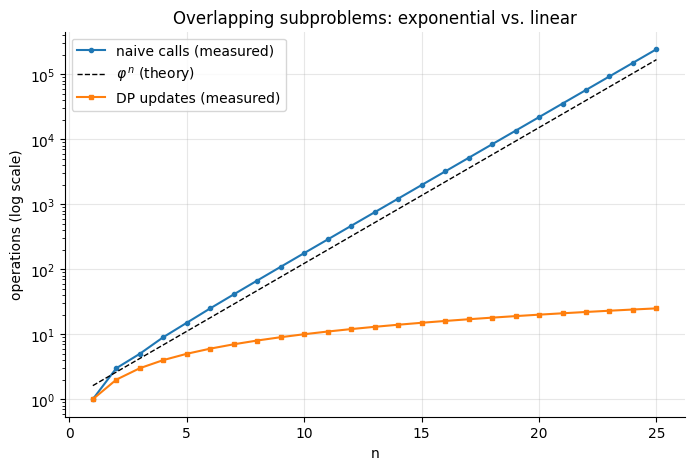

In [7]:
def fib_naive_calls(n, counter):
    counter[0] += 1
    if n < 2: return n
    return fib_naive_calls(n-1, counter) + fib_naive_calls(n-2, counter)

ns = range(1, 26)
naive = []
for n in ns:
    c = [0]; fib_naive_calls(n, c); naive.append(c[0])
naive = np.array(naive)
dp = np.array(list(ns))                # one update per index
phi = (1 + np.sqrt(5)) / 2

fig, ax = plt.subplots()
ax.plot(list(ns), naive, 'o-', ms=3, label='naive calls (measured)')
ax.plot(list(ns), phi**np.array(ns), 'k--', lw=1, label=r'$\varphi^{\,n}$ (theory)')
ax.plot(list(ns), dp, 's-', ms=3, label='DP updates (measured)')
ax.set_yscale('log')
ax.set_xlabel('n'); ax.set_ylabel('operations (log scale)')
ax.set_title('Overlapping subproblems: exponential vs. linear')
ax.legend()
plt.show()